# IP-level analysis

In [1]:
# Some imports
from cryptography.hazmat.backends import default_backend
from cryptography.x509.oid import ExtensionOID
from cryptography.x509.oid import NameOID
import matplotlib.pyplot as plt
from cryptography import x509
import collections
import aggregate6
import statistics
import ipaddress
import json

In [2]:
# Load certificates
certs = list()
with open("../data/certificates/certificates.json", "r") as f:
    for line in f:
        cert_str = json.loads(line)
        pem_bytes = cert_str.encode('utf-8')
        cert = x509.load_pem_x509_certificate(pem_bytes, default_backend())
        certs.append(cert)

In [3]:
# Analyze the SANs

# Store unique IPs per CA
ips_per_ca = collections.defaultdict(set)

# Store the number of identifiers per certificate
san_domains, san_ips = 0, 0
san_ipv4, san_ipv6 = 0, 0
# Store the counts of IPs per certificate
san_ips_per_cert = list()
# Find certificates containing both IPs and domains
san_ip_and_domain = 0
# Find certificates containing neither IPs nor domains
san_ids_non_ip_domain = 0
# Store certs with over 200 certificates
certs_san_ips_200 = list()

for cert in certs:
    # Get SAN
    san = cert.extensions.get_extension_for_oid(ExtensionOID.SUBJECT_ALTERNATIVE_NAME).value
    # Get the issuer
    for attribute in cert.issuer:
        if attribute.oid == NameOID.ORGANIZATION_NAME:
            issuer_org = attribute.value
    # Local to cert domains and IPs
    domains, ips = 0, 0
    for identifier in san:
        if isinstance(identifier,x509.IPAddress):
            ips_per_ca[issuer_org].add(str(identifier))
            ips += 1
            # Detect v4 and v6
            if ":" in str(identifier):
                san_ipv6 += 1
            else:
                san_ipv4 += 1
        elif isinstance(identifier,x509.DNSName):
            domains += 1
        else:
            san_ids_non_ip_domain += 1
    # Count of IPs per cert
    san_ips_per_cert.append(ips)
    # Total count of IPs and domains
    san_ips += ips
    san_domains += domains
    # Certs with both IPs and domains
    if domains and ips:
        san_ip_and_domain += 1
    # Certs with over 200 IPs
    if len(san) >= 200:
        certs_san_ips_200.append((issuer_org,san))

print(f"{san_ids_non_ip_domain} have identifiers that are neither IPs nor domains")
print(f"-----")
print(f"{len(certs):,} certificates contain {san_domains:,} domains and {san_ips:,} IPs ({san_ipv4:,} IPv4 and {san_ipv6:,} IPv6) inside SAN")
print(f"-----")
print(f"{san_ip_and_domain:,} certificates contain both domains and IPs")

0 have identifiers that are neither IPs nor domains
-----
517,619 certificates contain 224,207 domains and 582,753 IPs (566,845 IPv4 and 15,908 IPv6) inside SAN
-----
193,203 certificates contain both domains and IPs


In [4]:
# Distribution of IP counts per cert
san_ips_per_cert_count = collections.Counter(san_ips_per_cert)
print(f"Number of SAN IPs per certificate (out of {len(san_ips_per_cert_count)} values):")
for san,count in san_ips_per_cert_count.most_common(n=5):
    print(f"  {san}: {count:,} certificates {round(count*100/len(certs),2)}%")

print(f"  ---")
print(f"  Min: {min(san_ips_per_cert)}")
print(f"  Max: {max(san_ips_per_cert)}")
print(f"  Mean: {statistics.mean(san_ips_per_cert)}")
print(f"  Median: {statistics.median(san_ips_per_cert)}")
print(f"  ---") 
print(f"  {len([i for i in san_ips_per_cert if i >= 10]):,} certificates have 10+ IPs")
print(f"  {len([i for i in san_ips_per_cert if i >= 50])} certificates have 50+ IPs")
print(f"  {len([i for i in san_ips_per_cert if i >= 100])} certificates have 100+ IPs")
print(f"  {len([i for i in san_ips_per_cert if i >= 200])} certificates have 200+ IPs")

Number of SAN IPs per certificate (out of 102 values):
  1: 497,684 certificates 96.15%
  2: 16,696 certificates 3.23%
  3: 634 certificates 0.12%
  5: 429 certificates 0.08%
  10: 319 certificates 0.06%
  ---
  Min: 1
  Max: 250
  Mean: 1.1258338662220668
  Median: 1
  ---
  1,180 certificates have 10+ IPs
  296 certificates have 50+ IPs
  86 certificates have 100+ IPs
  12 certificates have 200+ IPs


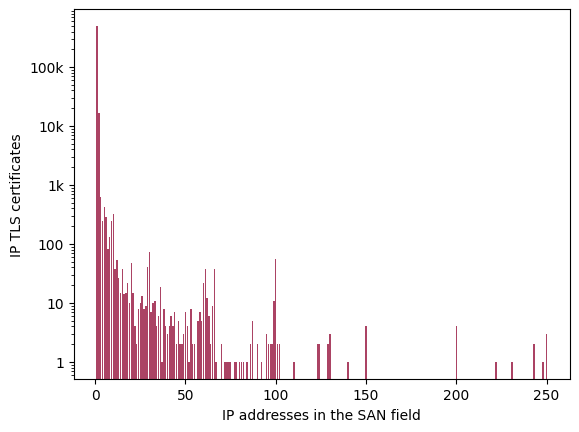

In [5]:
# Plot the distribution of IPs per certificate

x = sorted(san_ips_per_cert_count.keys())
y = [san_ips_per_cert_count[i] for i in x]

plt.bar(x, y, color='#ab4364')
plt.yscale("log")
plt.yticks([1, 10, 100, 1000, 10000, 100000], ["1", "10", "100", "1k", "10k", "100k"]) 
plt.xlabel("IP addresses in the SAN field")
plt.ylabel("IP TLS certificates")

plt.savefig(f"../data/figures/ips_per_san.pdf",bbox_inches='tight')
plt.show()

In [6]:
# Analyze the case of 200+ IPs
for issuer,san_ips in certs_san_ips_200:
    ips = [str(i.value) for i in san_ips]
    ips_24 = [str(ipaddress.ip_network(f"{i}/24", strict=False)) for i in ips]
    print(f"{issuer}: {len(ips)} IPs -> {len(aggregate6.aggregate(ips))} networks -> {aggregate6.aggregate(ips_24)} 24s")

# GlobalSign nv-sa: 250 IPs -> 11 networks -> ['146.103.83.0/24'] 24s -> Meteverse Limited
# GlobalSign nv-sa: 200 IPs -> 9 networks -> ['146.103.73.0/24'] 24s -> Meteverse Limited
# GlobalSign nv-sa: 200 IPs -> 8 networks -> ['146.103.92.0/24'] 24s -> Meteverse Limited
# GlobalSign nv-sa: 200 IPs -> 8 networks -> ['174.35.80.0/24'] 24s -> Meteverse Limited
# GlobalSign nv-sa: 200 IPs -> 9 networks -> ['153.43.10.0/24'] 24s -> Meteverse Limited
# GlobalSign nv-sa: 250 IPs -> 11 networks -> ['153.43.14.0/24'] 24s  -> Meteverse Limited

# TrustAsia Technologies, Inc.: 243 IPs -> 36 networks -> ['196.63.144.0/22'] 24s -> Afrinic
# TrustAsia Technologies, Inc.: 243 IPs -> 36 networks -> ['196.63.148.0/22'] 24s -> Afrinic
# TrustAsia Technologies, Inc.: 231 IPs -> 56 networks -> ['38.6.248.0/21'] 24s -> 	PEG TECH INC
# Sectigo Limited: 250 IPs -> 13 networks -> ['154.202.255.0/24'] 24s -> Charter Communications Inc
# Sectigo Limited: 222 IPs -> 44 networks -> ['156.226.88.0/22'] 24s -> CloudFly Net Inc
# Sectigo Limited: 248 IPs -> 39 networks -> ['23.248.199.0/24', '23.248.254.0/24', '156.234.15.0/24', '156.234.85.0/24', '156.234.211.0/24'] 24s -> different ones


GlobalSign nv-sa: 250 IPs -> 11 networks -> ['153.43.14.0/24'] 24s
TrustAsia Technologies, Inc.: 243 IPs -> 36 networks -> ['196.63.144.0/22'] 24s
GlobalSign nv-sa: 200 IPs -> 8 networks -> ['174.35.80.0/24'] 24s
TrustAsia Technologies, Inc.: 243 IPs -> 36 networks -> ['196.63.148.0/22'] 24s
Sectigo Limited: 250 IPs -> 13 networks -> ['154.202.255.0/24'] 24s
GlobalSign nv-sa: 200 IPs -> 8 networks -> ['146.103.92.0/24'] 24s
GlobalSign nv-sa: 200 IPs -> 9 networks -> ['146.103.73.0/24'] 24s
Sectigo Limited: 248 IPs -> 39 networks -> ['23.248.199.0/24', '23.248.254.0/24', '156.234.15.0/24', '156.234.85.0/24', '156.234.211.0/24'] 24s
GlobalSign nv-sa: 250 IPs -> 11 networks -> ['146.103.83.0/24'] 24s
Sectigo Limited: 222 IPs -> 44 networks -> ['156.226.88.0/22'] 24s
TrustAsia Technologies, Inc.: 231 IPs -> 56 networks -> ['38.6.248.0/21'] 24s
GlobalSign nv-sa: 200 IPs -> 9 networks -> ['153.43.10.0/24'] 24s


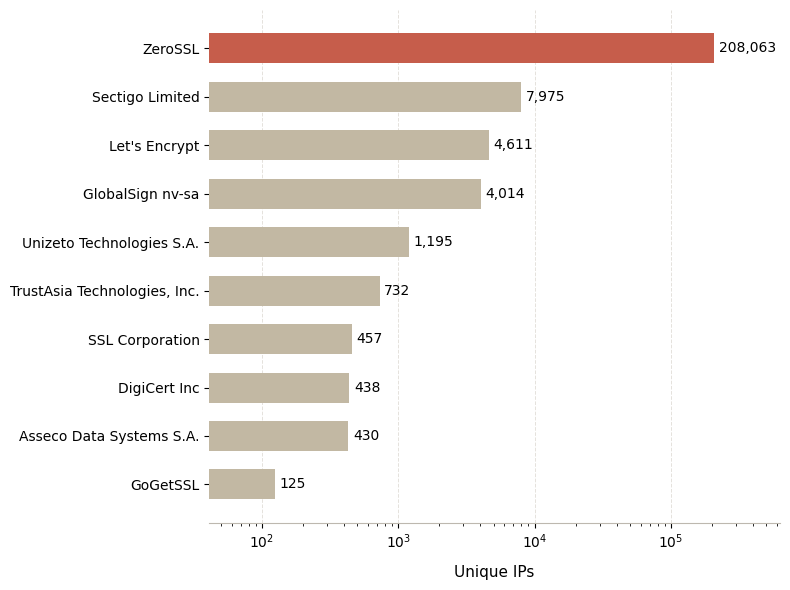

In [7]:
# Count and plot the number of unique IPs per CA

ips_per_ca_count = sorted([(i,len(ips_per_ca[i])) for i in ips_per_ca], key=lambda tup: tup[1], reverse=True)
labels = [i[0] for i in ips_per_ca_count[:10]]
values = [i[1] for i in ips_per_ca_count[:10]]

fig, ax = plt.subplots(figsize=(8, 6))

bar_colors = ["#C2B8A3" if label != "ZeroSSL" else "#C65D4B" for label in labels]
bars = ax.barh(labels, values, height=0.62, color=bar_colors)
ax.invert_yaxis()
ax.set_xscale("log")
for bar, value in zip(bars, values):
    ax.text( value * 1.08, bar.get_y() + bar.get_height() / 2, f"{value:,}", va="center", fontsize=10)

ax.set_xlabel("Unique IPs", fontsize=11, labelpad=10)
ax.grid(axis="x", linestyle="--", linewidth=0.7, color="#D9D5CE", alpha=0.7)

ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color("#BDB8AF")
ax.margins(x=0.15)

plt.tight_layout()
plt.savefig(f"../data/figures/ips_per_ca_unique.pdf",bbox_inches='tight')
plt.show()